# Network activity

[The previous notebook](./2.1%20Anatomical%20embedding.ipynb) provided us with an anatomical reconstruction of the barrel cortex, defining locations of presynaptic cells, and post-synaptic targets onto our cell. Given this anatomical data, we can now activate the synapses according to experimental data.

To do this, we need the following information
 1. A parameter file specifying characteristics of the synaspses by celltype
 2. A parameterfile specifying the ongoing activity by celltype
 3. Parameterfiles specifying evoked response by stimulus, celltype and cell location

In [1]:
from pathlib import Path
tutorial_output_dir = f"{Path.home()}/isf_tutorial_output"  # <-- Change this to your desired output directory

In [2]:
import Interface as I
%matplotlib inline

[INFO] ISF: Current version: heads/scim+0.ga89128f8e.dirty
[INFO] ISF: Current pid: 3997770
[INFO] l5pt: Loaded mechanisms in NEURON namespace.


--No graphics will be displayed.


[ATTENTION] ISF: The source folder has uncommited changes!



[INFO] ISF: Loaded modules with __version__ attribute are:
IPython: 8.18.1, Interface: heads/scim+0.ga89128f8e.dirty, PIL: 11.3.0, _brotli: 1.1.0, _csv: 1.0, _ctypes: 1.1.0, _curses: b'2.2', _decimal: 1.70, argparse: 1.1, blosc: 1.11.3, bluepyopt: 1.9.126, brotli: 1.1.0, certifi: 2025.08.03, charset_normalizer: 3.4.3, click: 7.1.2, cloudpickle: 3.1.1, colorama: 0.4.6, comm: 0.2.3, csv: 1.0, ctypes: 1.1.0, cycler: 0.12.1, cytoolz: 1.0.1, dash: 2.18.2, dask: 2.30.0, dateutil: 2.9.0.post0, deap: 1.4, debugpy: 1.8.16, decimal: 1.70, decorator: 5.2.1, defusedxml: 0.7.1, distributed: 2.30.0, distutils: 3.9.23, entrypoints: 0.4, exceptiongroup: 1.3.0, executing: 2.2.0, fasteners: 0.17.3, flask: 1.1.4, fsspec: 2025.7.0, future: 1.0.0, greenlet: 3.2.4, idna: 3.10, ipaddress: 1.0, ipykernel: 6.29.5, ipywidgets: 8.1.7, isf_pandas_msgpack: 0.4.0, itsdangerous: 1.1.0, jedi: 0.19.2, jinja2: 2.11.3, joblib: 1.5.1, json: 2.0.9, jupyter_clie

## Exploring the data

### Ongoing activity

In [3]:
from getting_started import getting_started_dir
ongoing_data_dir = Path(getting_started_dir) / 'example_data' / 'functional_constraints' / 'ongoing_activity'

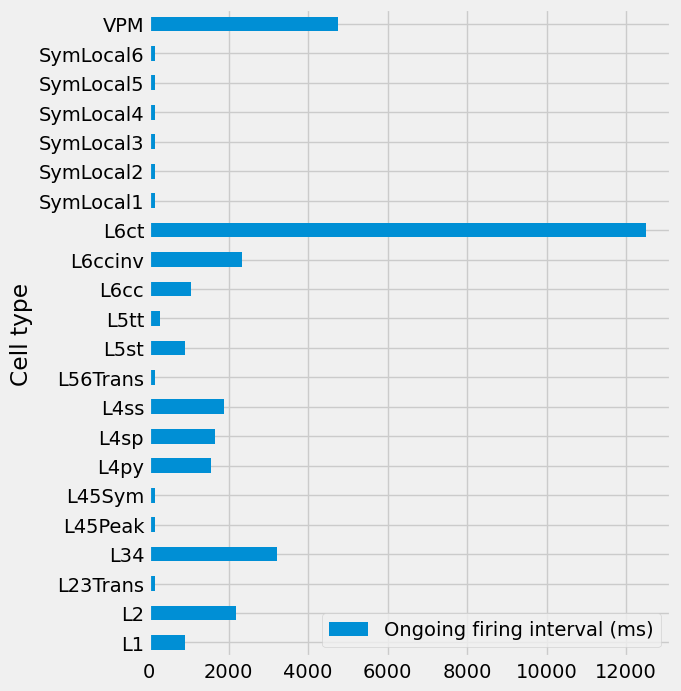

In [4]:
I.plt.style.use("fivethirtyeight")
ongoing_rates = I.pd.read_csv(ongoing_data_dir / "measured_ongoing_rates.csv", sep='\t')
ongoing_rates.set_index("Cell type").plot.barh(figsize=(6, 8));

We can see that ongoing activity is defined in terms of average interval (in $ms$) for each cell type.

Important for later: there is no distinction between where these cells are located. Ongoing activity is expected to be the same across cells of the same cell type, independent of where they are located.

### Evoked activity

Evoked activity captures the network activity during a specific *in vivo* condition.

The experimental condition we will consider here is a passive whisker touch of the rat.
We have files capturing the activity of all celltypes in all locations across the rat barrel cortex.
Let's see what these files look like:

In [5]:
evoked_activity_dir = Path(getting_started_dir) / "example_data" / "functional_constraints" / "evoked_activity"
evoked_activity_files = list(evoked_activity_dir.glob("*.param"))
[str(paramfile.name) for paramfile in evoked_activity_files]

['L2.param',
 'L56Trans.param',
 'L4ss.param',
 'L23Trans.param',
 'VPM.param',
 'SymLocal4.param',
 'L4sp.param',
 'L6ccinv.param',
 'SymLocal3.param',
 'L6cc.param',
 'SymLocal6.param',
 'SymLocal2.param',
 'L34.param',
 'L4py.param',
 'L5st.param',
 'L6ct.param',
 'L45Sym.param',
 'L45Peak.param',
 'SymLocal5.param',
 'L5tt.param',
 'SymLocal1.param']

Let's check what's inside these data files

In [6]:
I.scp.build_parameters(evoked_activity_files[0]).as_dict()

{'L2_B1': {'distribution': 'PSTH',
  'intervals': [[6.0, 7.0],
   [11.0, 12.0],
   [19.0, 20.0],
   [21.0, 22.0],
   [25.0, 26.0]],
  'probabilities': [0.0029, 0.0029, 0.0013, 0.0013, 0.0013]},
 'L2_B2': {'distribution': 'PSTH',
  'intervals': [[4.0, 5.0],
   [8.0, 9.0],
   [24.0, 25.0],
   [27.0, 28.0],
   [34.0, 35.0],
   [38.0, 39.0],
   [39.0, 40.0],
   [40.0, 41.0],
   [41.0, 42.0],
   [42.0, 43.0],
   [45.0, 46.0]],
  'probabilities': [0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013]},
 'L2_B3': {'distribution': 'PSTH',
  'intervals': [[4.0, 5.0],
   [9.0, 10.0],
   [25.0, 26.0],
   [31.0, 32.0],
   [43.0, 44.0],
   [49.0, 50.0]],
  'probabilities': [0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013]},
 'L2_C1': {'distribution': 'PSTH',
  'intervals': [[3.0, 4.0],
   [6.0, 7.0],
   [15.0, 16.0],
   [37.0, 38.0],
   [40.0, 41.0],
   [45.0, 46.0],
   [46.0, 47.0]],
  'probabilities': [0.0013, 0.0013, 0.0013, 0.0013, 

These files are [Activity data files](https://mpinb.github.io/in_silico_framework/file_formats.html#activity-data). They define empirically measured Post-Synaptic Time Histograms (PSTHs) of various cell types!

A small caveat here: you can see that these cell types are suffixed with e.g. `"_B2"`. What does that mean?
Let's check the readme:

In [7]:
print(
    Path(evoked_activity_dir / "readme.md").read_text()
)

De Kock, C. P. J., Bruno, R. M., Spors, H., & Sakmann, B. (2007). Layer- and cell-type-specific suprathreshold stimulus representation in rat primary somatosensory cortex. The Journal of Physiology, 581(1), 139–154. https://doi.org/10.1113/jphysiol.2006.124321

# Info about this data

All data in this directory contains activity data for various cell types in the juvenile Wistar rat Barrel Cortex.
All recordings were made in the C2 column.
Data is split so that each file contains one particular cell type.
Within each file, you will find multiple activity measurements for a single cell type. These correspond to 
different whisker deflections.

So e.g. "L6cc_B2" means the activity of a L6cc (located in C2) when deflecting a whisker in B2.

## Attention
Note that the suffix in these files does **NOT** correspond to the location of the recorded cell, in contrast to most other data in this repo.
It corresponds to the identity of the deflected whisker.

## Hint
While this repo only contains 

So `"_B2"` does not mean the cell was located in the B2 column. It is located in the C2 column, and the suffix means which whisker was deflected.

For convenience, we merge this data in a single variable

In [8]:
evoked_activity = I.scp.NTParameterSet({})
for evoked in evoked_activity_files: evoked_activity.update(I.scp.build_parameters(evoked))
evoked_activity

NTParameterSet({'L2_B1': {'distribution': 'PSTH', 'intervals': [[6.0, 7.0], [11.0, 12.0], [19.0, 20.0], [21.0, 22.0], [25.0, 26.0]], 'probabilities': [0.0029, 0.0029, 0.0013, 0.0013, 0.0013]}, 'L2_B2': {'distribution': 'PSTH', 'intervals': [[4.0, 5.0], [8.0, 9.0], [24.0, 25.0], [27.0, 28.0], [34.0, 35.0], [38.0, 39.0], [39.0, 40.0], [40.0, 41.0], [41.0, 42.0], [42.0, 43.0], [45.0, 46.0]], 'probabilities': [0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013]}, 'L2_B3': {'distribution': 'PSTH', 'intervals': [[4.0, 5.0], [9.0, 10.0], [25.0, 26.0], [31.0, 32.0], [43.0, 44.0], [49.0, 50.0]], 'probabilities': [0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013]}, 'L2_C1': {'distribution': 'PSTH', 'intervals': [[3.0, 4.0], [6.0, 7.0], [15.0, 16.0], [37.0, 38.0], [40.0, 41.0], [45.0, 46.0], [46.0, 47.0]], 'probabilities': [0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013]}, 'L2_C2': {'distribution': 'PSTH', 'intervals': [[1.0, 2.0], [4.0, 5.0], [5.0, 6.0],

Let's see what these PSTHs actually look like:

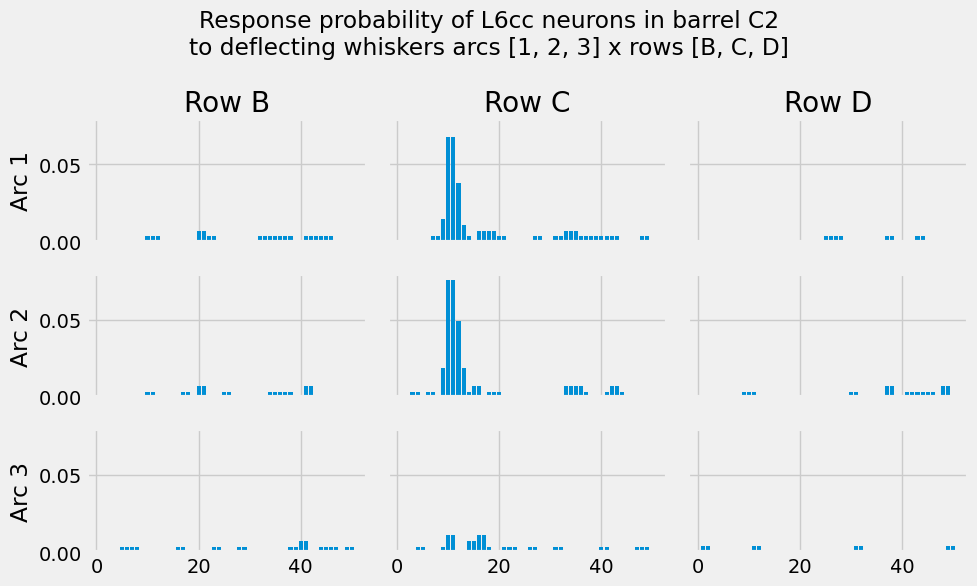

In [9]:
%matplotlib inline
I.plt.style.use("fivethirtyeight")
rows, cols = (1, 2, 3), ("B", "C", "D")
fig, axs = I.plt.subplots(len(rows), len(cols), sharey=True, sharex=True, figsize=(10, 6))

cell_type = "L6cc"
L6cc_activity = I.scp.build_parameters(evoked_activity_dir / f"{cell_type}.param")

for celltype_stimwhisker, psth in L6cc_activity.items():
    p, bins = psth['probabilities'], psth['intervals']
    stimwhisker = celltype_stimwhisker.split('_')[-1]
    row, arc = stimwhisker
    ax_row_ind, ax_col_ind = rows.index(int(arc)), cols.index(row)
    for b, p_ in zip(bins, p):
        axs[ax_row_ind, ax_col_ind].bar(b, p_, color="C0")
    if ax_col_ind == 0: axs[ax_row_ind, ax_col_ind].set_ylabel("Arc {}".format(rows[ax_row_ind]))
    if ax_row_ind == 0: axs[ax_row_ind, ax_col_ind].set_title("Row {}".format(cols[ax_col_ind]))

I.plt.suptitle(f"Response probability of {cell_type} neurons in barrel C2\nto deflecting whiskers arcs [1, 2, 3] x rows [B, C, D]")
fig.tight_layout()
I.plt.show()

### Synapse dynamics

We provide some default synapse dynamics models for glutamate and GABA receptors.

In [10]:
exc_syn_fn = Path(getting_started_dir) / "example_data" / "functional_constraints" / "exc_synapse_template.param"
I.scp.build_parameters(exc_syn_fn).as_dict()

{'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
    'delay': 0.0,
    'parameter': {'tau1': 26.0,
     'tau2': 2.0,
     'tau3': 2.0,
     'tau4': 0.1,
     'decayampa': 1.0,
     'decaynmda': 1.0},
    'weight': [1.0, 1.0]}},
  'releaseProb': 0.6}}

## Building a network parameter file

[Network parameter files](https://mpinb.github.io/in_silico_framework/file_formats#network-parameters) contain cell type-specific information on the following:
- The network embedding (see the [previous tutorial](./2.1%20Anatomical%20embedding.ipynb))
- Synapse dynamics
- Network activity (ongoing and/or evoked)


Here, we use [`NetworkParameterBuilder`](../../../singlecell_input_mapper/network_parameter_builder.py) to add each component to a single cohesive parameter file. You could do this in a single line of code, but we will instead add each component one by one to inspect and explain the intermediate results.


### Adding ongoing activity

In [11]:
from singlecell_input_mapper.network_param_builder import NetworkParamBuilder

celltype_to_ongoing_map = dict(
    zip(ongoing_rates['Cell type'], ongoing_rates['Ongoing firing interval (ms)'])
)

netp = NetworkParamBuilder().add_ongoing_activity(
    # Mapping between cell type and ongoing rate
    ongoing_interval_per_ct = celltype_to_ongoing_map

).network_parameters

netp.as_dict()

{'info': {},
 'network': {'L1': {'celltype': {'spiketrain': {'interval': 909.1}}},
  'L2': {'celltype': {'spiketrain': {'interval': 2173.9}}},
  'L23Trans': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L34': {'celltype': {'spiketrain': {'interval': 3225.8}}},
  'L45Peak': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L45Sym': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L4py': {'celltype': {'spiketrain': {'interval': 1562.5}}},
  'L4sp': {'celltype': {'spiketrain': {'interval': 1666.7}}},
  'L4ss': {'celltype': {'spiketrain': {'interval': 1886.8}}},
  'L56Trans': {'celltype': {'spiketrain': {'interval': 142.9}}},
  'L5st': {'celltype': {'spiketrain': {'interval': 909.1}}},
  'L5tt': {'celltype': {'spiketrain': {'interval': 283.3}}},
  'L6cc': {'celltype': {'spiketrain': {'interval': 1052.6}}},
  'L6ccinv': {'celltype': {'spiketrain': {'interval': 2325.6}}},
  'L6ct': {'celltype': {'spiketrain': {'interval': 12500.0}}},
  'SymLocal1': {'celltype': {'spiketrain'

### Adding synapse dynamics
To add synapse dynamics, you could provide a mapping from cell type to specific synapse parameters. However, for this tutorial, we will simply assign generic excitatory and inhibitory synapses, depending on the cell type. This is the default fallback behavior of the `NetworkParameterBuilder`.
Which cell types are excitatory or inhibitory should be configured in ISF's user configuration, located in the `config` directory.

In [12]:
netp = NetworkParamBuilder(netp).add_synapse_dynamics(
).network_parameters

netp.as_dict()

[WARNING] network_param_builder: No cell type specific synapse dynamics passed. Using generic synapse dynamics for excitatory and inhibitory instead. These can be configured in the user config.


{'info': {},
 'network': {'L1': {'celltype': {'spiketrain': {'interval': 909.1}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      'weight': 1.0}},
    'releaseProb': 0.25}},
  'L2': {'celltype': {'spiketrain': {'interval': 2173.9}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'decaynmda': 1.0},
      'weight': [1.0, 1.0]}},
    'releaseProb': 0.6}},
  'L23Trans': {'celltype': {'spiketrain': {'interval': 142.9}},
   'synapses': {'receptors': {'gaba_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'decaygaba': 1.0,
       'risetime': 1.0,
       'decaytime': 20.0,
       'facilgaba': 0.0,
       'e': -80.0},
      'weight': 1.0}},
    're

### Adding the network embedding

Note that network embedding data depends on the locations of each presynaptic cell:

In [13]:
# This was built in the previous tutorial
# Make sure that you don't have multiple files in there
# Here, we assume they are unique and simply fetch the first one we find
network_embedding_db = I.DataBase(tutorial_output_dir)['network_modeling']

I.pd.read_csv(
    network_embedding_db['anatomical_constraints'].get_file("NumberOfConnectedCells.csv"),
    sep="\t"
)

,Presynaptic column,Presynaptic cell type,Connected presynaptic cells
0,A1,L4py,9
1,A1,L6ct,0
2,A1,L5st,50
3,A1,L1,0
4,A1,L2,0
...,...,...,...
523,Gamma,SymLocal2,0
524,Gamma,SymLocal3,0
525,Gamma,VPM,3
526,Gamma,SymLocal4,1


To add this to our network parameters, we must first subcategorize it so it has the same cell types. We can split up existing cell types into more refined categories. Each subtype will still have the same information as the original aggregate cell type:

In [14]:
subcategorized_celltypes_map = {
    ct: [subct for subct in evoked_activity.keys() if subct.startswith(ct)] 
    for ct in netp.network
}

# Example
subcategorized_celltypes_map['L5tt']

['L5tt_B1',
 'L5tt_B2',
 'L5tt_B3',
 'L5tt_C1',
 'L5tt_C2',
 'L5tt_C3',
 'L5tt_D1',
 'L5tt_D2',
 'L5tt_D3']

In [15]:
netp = NetworkParamBuilder(netp).subcategorize_celltypes(
    cell_type_map = subcategorized_celltypes_map
).network_parameters

netp.as_dict()

{'info': {},
 'network': {'L2_B1': {'celltype': {'spiketrain': {'interval': 2173.9}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'decaynmda': 1.0},
      'weight': [1.0, 1.0]}},
    'releaseProb': 0.6}},
  'L2_B2': {'celltype': {'spiketrain': {'interval': 2173.9}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'decaynmda': 1.0},
      'weight': [1.0, 1.0]}},
    'releaseProb': 0.6}},
  'L2_B3': {'celltype': {'spiketrain': {'interval': 2173.9}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'dec

Now, the cell types in the network parameters match the information from the network embedding. Let's add it:

In [16]:
netp = NetworkParamBuilder(netp).add_network_embedding(
    syn_fn = network_embedding_db['anatomical_constraints'].get_file(".syn"),
    con_fn = network_embedding_db['anatomical_constraints'].get_file(".con"),
).network_parameters

netp.as_dict()

{'info': {},
 'network': {'L2_B1': {'celltype': {'spiketrain': {'interval': 2173.9}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'decaynmda': 1.0},
      'weight': [1.0, 1.0]}},
    'releaseProb': 0.6,
    'distributionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/86_C2_center_synapses_20250821-1543_56117.syn',
    'connectionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/86_C2_center_synapses_20250821-1543_56117.con'},
   'cellNr': 75},
  'L2_B2': {'celltype': {'spiketrain': {'interval': 2173.9}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'd

This added our [.syn](https://mpinb.github.io/in_silico_framework/file_formats#syn) and [.con](https://mpinb.github.io/in_silico_framework/file_formats#con) file (just the filenames), as well as `"cellNr"`: the amount of connected presynaptic cells of this cell type.

### Adding evoked activity

Evoked activity data in our case depends on which whisker was stimulated (see [explanation above](#evoked-activity))

In [17]:
evoked_activity.keys()

dict_keys(['L2_B1', 'L2_B2', 'L2_B3', 'L2_C1', 'L2_C2', 'L2_C3', 'L2_D1', 'L2_D2', 'L2_D3', 'L56Trans_B1', 'L56Trans_B2', 'L56Trans_B3', 'L56Trans_C1', 'L56Trans_C2', 'L56Trans_C3', 'L56Trans_D1', 'L56Trans_D2', 'L56Trans_D3', 'L4ss_B1', 'L4ss_B2', 'L4ss_B3', 'L4ss_C1', 'L4ss_C2', 'L4ss_C3', 'L4ss_D1', 'L4ss_D2', 'L4ss_D3', 'L23Trans_B1', 'L23Trans_B2', 'L23Trans_B3', 'L23Trans_C1', 'L23Trans_C2', 'L23Trans_C3', 'L23Trans_D1', 'L23Trans_D2', 'L23Trans_D3', 'VPM_B1', 'VPM_B2', 'VPM_B3', 'VPM_C1', 'VPM_C2', 'VPM_C3', 'VPM_D1', 'VPM_D2', 'VPM_D3', 'SymLocal4_B1', 'SymLocal4_B2', 'SymLocal4_B3', 'SymLocal4_C1', 'SymLocal4_C2', 'SymLocal4_C3', 'SymLocal4_D1', 'SymLocal4_D2', 'SymLocal4_D3', 'L4sp_B1', 'L4sp_B2', 'L4sp_B3', 'L4sp_C1', 'L4sp_C2', 'L4sp_C3', 'L4sp_D1', 'L4sp_D2', 'L4sp_D3', 'L6ccinv_B1', 'L6ccinv_B2', 'L6ccinv_B3', 'L6ccinv_C1', 'L6ccinv_C2', 'L6ccinv_C3', 'L6ccinv_D1', 'L6ccinv_D2', 'L6ccinv_D3', 'SymLocal3_B1', 'SymLocal3_B2', 'SymLocal3_B3', 'SymLocal3_C1', 'SymLocal3_C2', 

Also remember that the suffix in these files corresponds to *which whisker* was stimulated. This is **not** the same as the celltypes we have so far in our network parameters, which correspond to *where* the cell is located. The activity data only contains recordings in the C2 column.

However, we can augment the data a bit. If we assume network activity looks the same depending on which whisker was stimulated *relative* to where we want to record, we can effectively grab activity data from our C2-located recordings, for an equivalent stimulated whisker of the same relative coordinate:

In [18]:
# Assign (row, col) coordinates to every whisker column
COL_TO_RELCO = {
    'Alpha': (-3, -1), 'Beta': (-3, 0), 'Gamma': (-3, 1), 'Delta': (-3, 2),
    'A1':    (-2, -1), 'A2':   (-2, 0), 'A3':    (-2, 1),  'A4':   (-2, 2),
    'B1':    (-1, -1), 'B2':   (-1, 0), 'B3':    (-1, 1),  'B4':   (-1, 2),
    'C1':    ( 0, -1), 'C2':   ( 0, 0), 'C3':    ( 0, 1),  'C4':   ( 0, 2),
    'D1':    ( 1, -1), 'D2':   ( 1, 0), 'D3':    ( 1, 1),  'D4':   ( 1, 2),
    'E1':    ( 2, -1), 'E2':   ( 2, 0), 'E3':    ( 2, 1),  'E4':   ( 2, 2),
}

def get_equiv_stimwhisker_for_c2_recording(recording_column, deflected_whisker, constrain_to_3x3=True) -> str:
    # Relative coordinate of the recording column
    vec_c2_to_recording_column = COL_TO_RELCO[recording_column]
    # Relative coordinate of the stimulated whisker
    vec_c2_to_whisker = COL_TO_RELCO[deflected_whisker]

    vec_stimwhisker_to_recording_column = tuple(
        b - a 
        for a, b in zip(vec_c2_to_whisker, vec_c2_to_recording_column)
    )

    if any([abs(e) > 1 for e in vec_stimwhisker_to_recording_column]) and constrain_to_3x3:
        # requested configuration exceeds 3x3 grid
        # At least one recording column is more that one row or arc from the stimulated whisker
        return None

    vec_recording_column_to_stimwhisker = tuple(
        -e 
        for e in vec_stimwhisker_to_recording_column
    )
    # Vectors start at C2, since C2 is (0, 0), so this vector is already what we want
    vec_c2_to_equiv_stimwhisker = vec_recording_column_to_stimwhisker

    RELCO_TO_COL = {v: k for k, v in COL_TO_RELCO.items()}
    try:
        stimwhisker_rel_to_c2 = RELCO_TO_COL[vec_recording_column_to_stimwhisker]
    except KeyError: 
        # Requested recording column and whisker are not in 3x3 grid.
        return None
    return stimwhisker_rel_to_c2

# For example
recording_col = "B1"
deflect_whisker = "C2"
equiv_stimwhisker = get_equiv_stimwhisker_for_c2_recording(
    recording_column=recording_col,
    deflected_whisker=deflect_whisker
)

print(
f"Simulating a {deflect_whisker} whisker simulus and recording from {recording_col} has activity",
f"similar to the empirically recorded activity when stimulating {equiv_stimwhisker} (and recording from C2)"
)

Simulating a C2 whisker simulus and recording from B1 has activity similar to the empirically recorded activity when stimulating D3 (and recording from C2)


So in order to know the activity of all cell types, we must know which whisker we want to stimulate.

In [19]:
# Our cell is also at C2. This is called a "Principle Whisker (PW)" stimulus, since the recorded cell and whisker are in the same column
simulate_stimwhisk = "C2"

In [20]:
inferred_evoked_activity = I.scp.NTParameterSet({})

for celltype_column in netp.network:
    celltype, column = celltype_column.split("_")
    equiv_whisker = get_equiv_stimwhisker_for_c2_recording(recording_column=column, deflected_whisker=simulate_stimwhisk)
    if equiv_whisker == None: continue
    activity_data = evoked_activity.get(f"{celltype}_{equiv_whisker}", None)
    if activity_data != None:
        inferred_evoked_activity[celltype_column] = activity_data

inferred_evoked_activity.as_dict()

{'L2_B1': {'distribution': 'PSTH',
  'intervals': [[2.0, 3.0],
   [15.0, 16.0],
   [17.0, 18.0],
   [25.0, 26.0],
   [26.0, 27.0],
   [31.0, 32.0],
   [40.0, 41.0],
   [49.0, 50.0]],
  'probabilities': [0.0015,
   0.0015,
   0.0015,
   0.0015,
   0.0015,
   0.0015,
   0.0015,
   0.0015]},
 'L2_B2': {'distribution': 'PSTH',
  'intervals': [[11.0, 12.0],
   [12.0, 13.0],
   [13.0, 14.0],
   [17.0, 18.0],
   [19.0, 20.0],
   [33.0, 34.0],
   [38.0, 39.0],
   [42.0, 43.0],
   [45.0, 46.0],
   [49.0, 50.0]],
  'probabilities': [0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0029,
   0.0013,
   0.0029,
   0.0029,
   0.0013]},
 'L2_B3': {'distribution': 'PSTH',
  'intervals': [[3.0, 4.0],
   [8.0, 9.0],
   [9.0, 10.0],
   [12.0, 13.0],
   [14.0, 15.0],
   [24.0, 25.0],
   [25.0, 26.0],
   [41.0, 42.0],
   [45.0, 46.0]],
  'probabilities': [0.0029,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013,
   0.0013]},
 'L2_C1': {'distribution': 'PSTH',
  'intervals

The above workflow of inferring which activity key we need depending on the cell type and the desired column can be automated in `NetworkParamBuilder` by means of a `key_modify_fun`.
Such function takes a cell type key (including the location), and adapts it for correspondance to a key in the activity data:

In addition, we would like this evoked activity to start after a predefined delay. 
This can later be set with the `offset` parameter in the [Network parameters](https://mpinb.github.io/in_silico_framework/file_formats.html#network-parameters) for each cell type. Keep this in mind when inspecting PSTHs that relate to evoked activity: they start at $0ms$, but during simulations, they start at `offset`.

In [21]:
offset = 245
additional_evoked_parameters = {"offset": offset}

In [22]:
from functools import partial

def key_modify_fun(celltype_column, whisker="C1"):
    celltype, column = celltype_column.split("_")
    equiv_whisker = get_equiv_stimwhisker_for_c2_recording(recording_column=column, deflected_whisker=simulate_stimwhisk)
    if equiv_whisker == None: return None
    else: return f"{celltype}_{equiv_whisker}"

netp = NetworkParamBuilder(netp).add_activity(
    activity_per_ct=evoked_activity,  # this is NOT activity per celltype as they are in the network, but we readjust with key_modify_fun
    key_modify_fun = partial(key_modify_fun, whisker=simulate_stimwhisk),
    additional_params = additional_evoked_parameters
).network_parameters

netp.as_dict()

[WARNING] network_param_builder: No activity data found under key: L1_D3
[WARNING] network_param_builder: No activity data found under key: L1_D2
[WARNING] network_param_builder: No activity data found under key: L1_D1
[WARNING] network_param_builder: No activity data found under key: L1_C3
[WARNING] network_param_builder: No activity data found under key: L1_C2
[WARNING] network_param_builder: No activity data found under key: L1_C1
[WARNING] network_param_builder: No activity data found under key: L1_B3
[WARNING] network_param_builder: No activity data found under key: L1_B2
[WARNING] network_param_builder: No activity data found under key: L1_B1


{'info': {},
 'network': {'L2_B1': {'celltype': {'spiketrain': {'interval': 2173.9},
    'pointcell': {'distribution': 'PSTH',
     'intervals': [[2.0, 3.0],
      [15.0, 16.0],
      [17.0, 18.0],
      [25.0, 26.0],
      [26.0, 27.0],
      [31.0, 32.0],
      [40.0, 41.0],
      [49.0, 50.0]],
     'probabilities': [0.0015,
      0.0015,
      0.0015,
      0.0015,
      0.0015,
      0.0015,
      0.0015,
      0.0015],
     'offset': 245}},
   'synapses': {'receptors': {'glutamate_syn': {'threshold': 0.0,
      'delay': 0.0,
      'parameter': {'tau1': 26.0,
       'tau2': 2.0,
       'tau3': 2.0,
       'tau4': 0.1,
       'decayampa': 1.0,
       'decaynmda': 1.0},
      'weight': [1.0, 1.0]}},
    'releaseProb': 0.6,
    'distributionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/anatomical_constraints/86_C2_center_synapses_20250821-1543_56117.syn',
    'connectionFile': '/gpfs/soma_fs/home/meulemeester/isf_tutorial_output/network_modeling/db/a

You can see how each cell type now has associated activity data of the form:

```py
'distribution': 'PSTH',
'intervals': [[...], [...], ...]
'probabilities': [...]
```

These are exactly the evoked activity patterns we have measured empirically, but reassigned so they match their equivalent column.

### Saving the result

In [23]:
netp.save(
    filename=network_embedding_db['network_param'].join(f'{simulate_stimwhisk}_stim.param')
)

### Automating the network parameter generation

Let's also generate parameterfiles for surround whisker stimuli! 

These will be used in [the next tutorial](../3.%20multiscale%20models/3.1%20Multiscale%20modeling.ipynb) to run multi-scale simulations.

In the example below, we generate an entire network parameter set from scratch. 

> CAREFUL: You could also simply adapt the existing one, since most of the information does not change when changing the stimulus. However, the NetworkParamBuilder is additive, not destructive. You can always add and overwrite existing parameters. But if you add something that does not cover all cell types (such as evoked activity), previous information will remain. This is likely not what you want.

In [ ]:
surround_whiskers = ['B1', 'B2', 'B3', 'C1', 'C3', 'D1', 'D2', 'D3']

nr_cells_fn = network_embedding_db['anatomical_constraints'].get_file("NumberOfConnectedCells.csv")
syn_fn      = network_embedding_db['anatomical_constraints'].get_file(".syn")
con_fn      = network_embedding_db['anatomical_constraints'].get_file(".con")

with I.silence_logger():
    for stimulated_whisker in surround_whiskers:
        save_filename=network_embedding_db['network_param'].join('{}_stim.param'.format(stimulated_whisker))
        netp = NetworkParamBuilder(
        ).add_ongoing_activity(
            ongoing_interval_per_ct = celltype_to_ongoing_map
        ).add_synapse_dynamics(
        ).subcategorize_celltypes(
            cell_type_map = subcategorized_celltypes_map
        ).add_network_embedding(
            syn_fn = syn_fn,
            con_fn = con_fn,
        ).add_activity(
            activity_per_ct=evoked_activity,  # this is NOT activity per celltype as they are in the network, but we readjust with key_modify_fun
            key_modify_fun = partial(key_modify_fun, whisker=stimulated_whisker),
            additional_params = additional_evoked_parameters,
        ).network_parameters
        netp.save(
            filename=save_filename
        )
        print(f"Saved {save_filename.split(I.os.sep)[-1]}")
    

Saved B1_stim.param
Saved B2_stim.param
Saved B3_stim.param
Saved C1_stim.param
Saved C3_stim.param
Saved D1_stim.param
Saved D2_stim.param
Saved D3_stim.param


And one more time to create parameterfiles for $2nd$ surround stimuli. 

These will be used in [Tutorial 4.2](../4.%20analysis/4.1%20Manipulations.ipynb) to manipulate synaptic input.

In [ ]:
second_surround_whiskers = [
    'A1', 'A2', 'A3', 'A4', 
    'E1', 'E2', 'E3', 'E4',
    'B4', 'C4', 'D4'
    ]

with I.silence_logger():
    for stimulated_whisker in second_surround_whiskers:
        save_filename=network_embedding_db['network_param'].join('{}_stim.param'.format(stimulated_whisker))
        netp = NetworkParamBuilder(
        ).add_ongoing_activity(
            ongoing_interval_per_ct = celltype_to_ongoing_map
        ).add_synapse_dynamics(
        ).subcategorize_celltypes(
            cell_type_map = subcategorized_celltypes_map
        ).add_network_embedding(
            syn_fn = syn_fn,
            con_fn = con_fn,
        ).add_activity(
            activity_per_ct=evoked_activity,  # this is NOT activity per celltype as they are in the network, but we readjust with key_modify_fun
            key_modify_fun = partial(key_modify_fun, whisker=stimulated_whisker),
            additional_params = additional_evoked_parameters
        ).network_parameters
        netp.save(
            filename=save_filename
        )
        print(f"Saved {save_filename.split(I.os.sep)[-1]}")

Saved A1_stim.param
Saved A2_stim.param
Saved A3_stim.param
Saved A4_stim.param
Saved E1_stim.param
Saved E2_stim.param
Saved E3_stim.param
Saved E4_stim.param
Saved B4_stim.param
Saved C4_stim.param
Saved D4_stim.param


## Inspecting the network activity

Let's visualize the response probabilities of each cell type, similar to what we did above.

In [27]:
network_param_C2 = I.scp.build_parameters(network_embedding_db['network_param'].join('C2_stim.param'))

In [28]:
surround_column_map = {
    'A1': {'Alpha': 4, 'A1': 5, 'A2': 6, 'B1': 8, 'B2': 9},\
    'A2': {'A1': 4, 'A2': 5, 'A3': 6, 'B1': 7, 'B2': 8, 'B3': 9},\
    'A3': {'A2': 4, 'A3': 5, 'A4': 6, 'B2': 7, 'B3': 8, 'B4': 9},\
    'A4': {'A3': 4, 'A4': 5, 'B3': 7, 'B4': 8},\
    'Alpha': {'Alpha': 5, 'A1': 6, 'Beta': 8, 'B1': 9},\
    'B1': {'Alpha': 1, 'A1': 2, 'A2': 3, 'Beta': 4, 'B1': 5, 'B2': 6, 'C1': 8, 'C2': 9},\
    'B2': {'A1': 1, 'A2': 2, 'A3': 3, 'B1': 4, 'B2': 5, 'B3': 6, 'C1': 7, 'C2': 8, 'C3': 9},\
    'B3': {'A2': 1, 'A3': 2, 'A4': 3, 'B2': 4, 'B3': 5, 'B4': 6, 'C2': 7, 'C3': 8, 'C4': 9},\
    'B4': {'A3': 1, 'A4': 2, 'B3': 4, 'B4': 5, 'C3': 7, 'C4': 8},\
    'Beta': {'Alpha': 2, 'Beta': 5, 'B1': 6, 'Gamma': 8, 'C1': 9},\
    'C1': {'Beta': 1, 'B1': 2, 'B2': 3, 'Gamma': 4, 'C1': 5, 'C2': 6, 'D1': 8, 'D2': 9},\
    'C2': {'B1': 1, 'B2': 2, 'B3': 3, 'C1': 4, 'C2': 5, 'C3': 6, 'D1': 7, 'D2': 8, 'D3': 9},\
    'C3': {'B2': 1, 'B3': 2, 'B4': 3, 'C2': 4, 'C3': 5, 'C4': 6, 'D2': 7, 'D3': 8, 'D4': 9},\
    'C4': {'B3': 1, 'B4': 2, 'C3': 4, 'C4': 5, 'D3': 7, 'D4': 8},\
    'Gamma': {'Beta': 2, 'Gamma': 5, 'C1': 6, 'Delta': 8, 'D1': 9},\
    'D1': {'Gamma': 1, 'C1': 2, 'C2': 3, 'Delta': 4, 'D1': 5, 'D2': 6, 'E1': 8, 'E2': 9},\
    'D2': {'C1': 1, 'C2': 2, 'C3': 3, 'D1': 4, 'D2': 5, 'D3': 6, 'E1': 7, 'E2': 8, 'E3': 9},\
    'D3': {'C2': 1, 'C3': 2, 'C4': 3, 'D2': 4, 'D3': 5, 'D4': 6, 'E2': 7, 'E3': 8, 'E4': 9},\
    'D4': {'C3': 1, 'C4': 2, 'D3': 4, 'D4': 5, 'E3': 7, 'E4': 8},\
    'Delta': {'Gamma': 2, 'Delta': 5, 'D1': 6, 'E1': 9},\
    'E1': {'Delta': 1, 'D1': 2, 'D2': 3, 'E1': 5, 'E2': 6},\
    'E2': {'D1': 1, 'D2': 2, 'D3': 3, 'E1': 4, 'E2': 5, 'E3': 6},\
    'E3': {'D2': 1, 'D3': 2, 'D4': 3, 'E2': 4, 'E3': 5, 'E4': 6},\
    'E4': {'D3': 1, 'D4': 2, 'E3': 4, 'E4': 5}}

def activity_gridplot(ct, deflected_whisker="C2", network_param=network_param_C2):
    surround_columns = surround_column_map[deflected_whisker]
    rows = list(set([e[1] for e in surround_columns]))
    n_rows = len(rows)
    columns = list(set([e[0] for e in surround_columns]))
    columns.sort()
    n_columns = len(columns)

    fig, axs = I.plt.subplots(n_rows, n_columns, sharey=True, sharex=True)
    for surround_column in surround_columns:
        row = int(surround_column[-1])
        column = surround_column[-2]
        axs[row-1][0].set_ylabel(row)
        axs[0][columns.index(column)].set_xlabel(column)
        axs[0][columns.index(column)].xaxis.set_label_position('top') 
        
        cell_type = ct+"_{}{}".format(column, row)
        if cell_type not in network_param.network.keys():
            continue
        if not 'pointcell' in network_param.network[cell_type]['celltype']:
            continue
        x = [b[0] for b in network_param.network[cell_type]['celltype']['pointcell']['intervals']]

        if row == 2 and column == "C":
            # barrel of the whisker deflection
            color = "C1"
        else:
            color = "Grey"
            
        bar = axs[row-1][columns.index(column)].bar(
            x, 
            network_param.network[cell_type]['celltype']['pointcell']['probabilities'], 
            facecolor=color, 
            edgecolor=color,
            lw=2)
    
    fig.suptitle(
        "Response probability of {} populations\nwhen deflecting whisker {}".format(
            ct, deflected_whisker))
    fig.tight_layout()
    return fig, axs

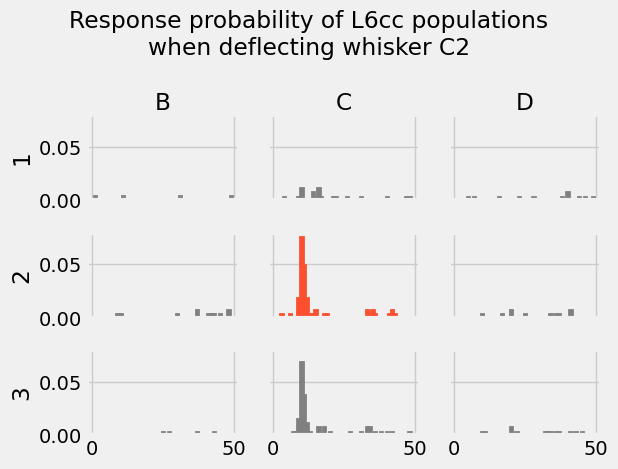

In [29]:
ct = "L6cc"
fig, axs = activity_gridplot(ct)
I.plt.show()

Note again that this time we are not visualizing the response probability of some neuron population to different inputs (like the first histogram grid). We are instead visualizing the response probabilities of different neuron populations to the same experimental condition: deflecting whisker C2.

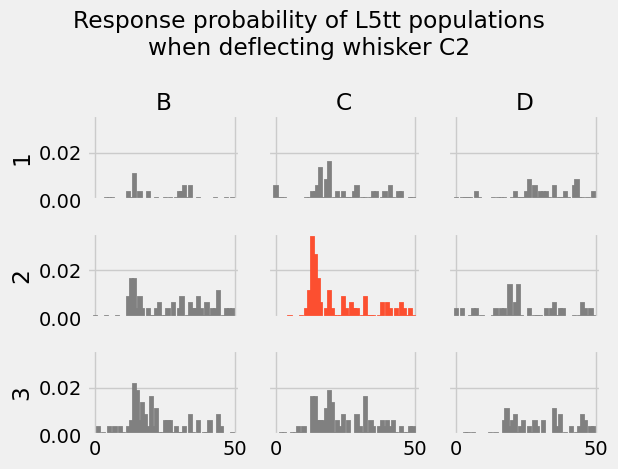

In [30]:
ct = "L5tt"
fig, axs = activity_gridplot(ct)
I.plt.show()

## Recap

[Tutorial 2.1](./2.1%20Anatomical%20embedding.ipynb) covered how to embed a neuron model into a network reconstruction, taking into account the relevant morphological, cellular and network properties. This tutorial covered how to generate synaptic activity. We are now ready to combine our biophysically detailed neuron model with this network model: see [Tutorial 3.1](../3.%20multiscale%20models/3.1%20Multiscale%20modeling.ipynb).